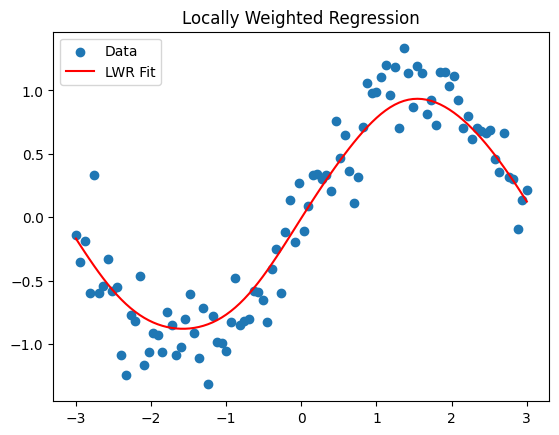

In [2]:
import numpy as np
import matplotlib.pyplot as plt

X = np.linspace(-3, 3, 100)
y = np.sin(X) + np.random.normal(0, 0.2, 100)

X_design = np.c_[np.ones(len(X)), X]

def locally_weighted_regression(X, y, tau):
    m = len(X)
    y_pred = np.zeros(m)
    
    for i in range(m):
        weights = np.exp(-(X[:,1] - X[i,1])**2 / (2 * tau**2))
        W = np.diag(weights)
        
        theta = np.linalg.pinv(X.T @ W @ X) @ (X.T @ W @ y)
        
    
        y_pred[i] = X[i] @ theta
    
    return y_pred

tau = 0.5 
y_lwr = locally_weighted_regression(X_design, y, tau)


plt.scatter(X, y, label="Data")
plt.plot(X, y_lwr, color='red', label="LWR Fit")
plt.legend()
plt.title("Locally Weighted Regression")
plt.show()